In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# conda install -c conda-forge control slycot
from control import tf, feedback, step_response, zpk, matlab, forced_response, nyquist_plot, margin, pzmap, poles, zeros
from scipy.signal import welch

In [ ]:
s = tf([1, 0], 1) # define laplace function

## Defining a plant (Simple harmonic oscillator)

In [ ]:
m = 1 # kg
k = 100 # N/m
b = 0.1 # N / (m/s)
plant = 1/(m * s**2 + b * s + k)
plant

TransferFunction(array([1]), array([  1. ,   0.1, 100. ]))

## Frequency response (Transfer function)

In [ ]:
freq = np.arange(0.001, 10000, 0.001)
plant_mag, plant_phase, _ = plant.frequency_response(2*np.pi*freq)

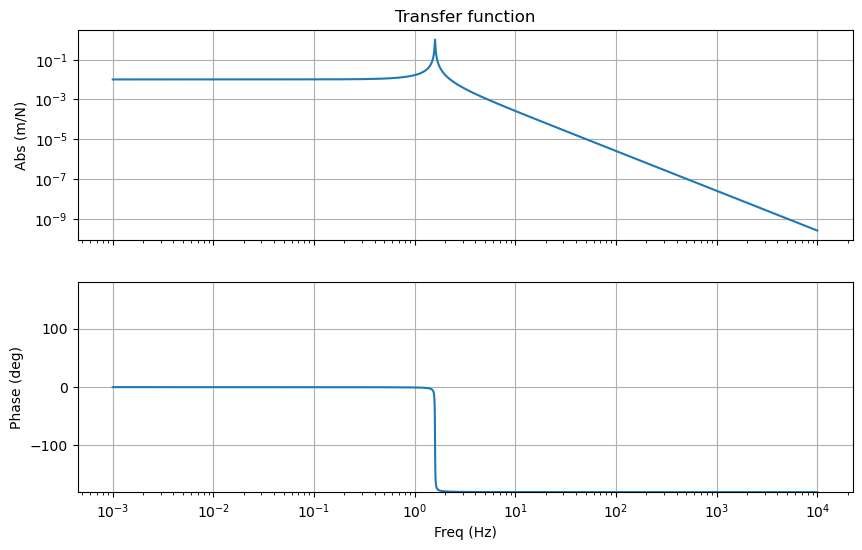

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, plant_mag)
axes[0].set_ylabel(r'Abs (m/N)')
axes[0].set_title('Transfer function')
axes[0].grid()

axes[1].semilogx(freq, plant_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

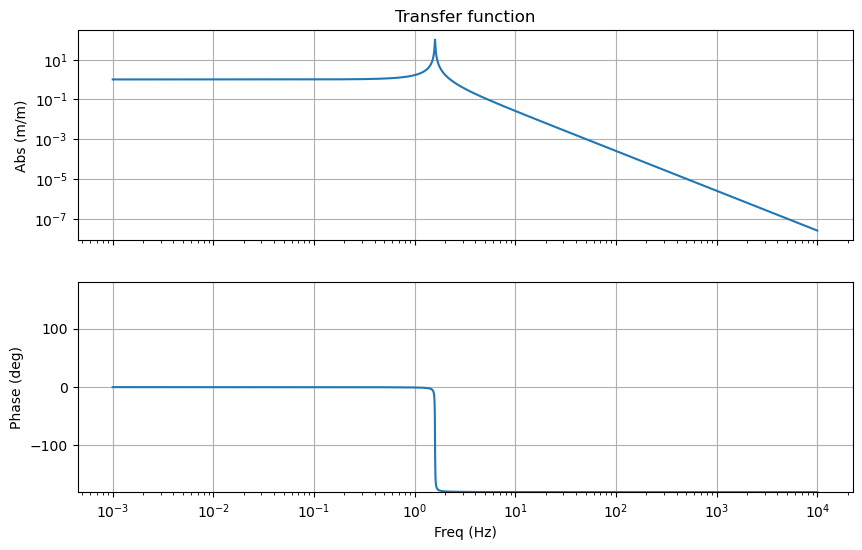

In [ ]:
# For convenience redefine the scaling from Netwon to meter (disturbance in terms of displacement instead force)
plant = k/(m * s**2 + b * s + k)
plant_mag, plant_phase, _ = plant.frequency_response(2*np.pi*freq)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, plant_mag)
axes[0].set_ylabel(r'Abs (m/m)')
axes[0].set_title('Transfer function')
axes[0].grid()

axes[1].semilogx(freq, plant_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

## Time response

In [ ]:
fs = 10000
time = np.linspace(0, 100, fs)
_, plant_step  = step_response(plant, time)

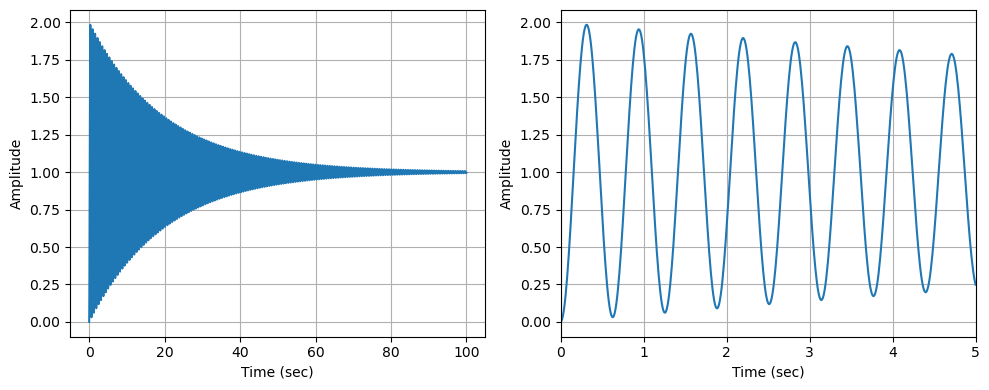

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

### Q-factor

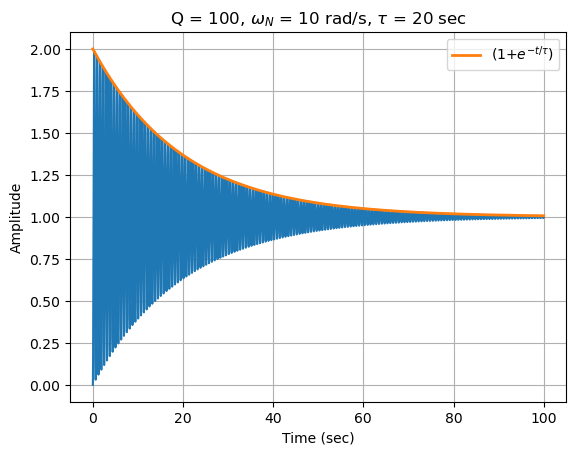

In [ ]:
Q = np.sqrt(k * m)/b
w_N = 10
tau = 2 * Q / w_N
plt.plot(time, plant_step)
plt.plot(time, 1+(np.exp(-time/tau)), label=r'(1+$e^{-t/\tau})$', linewidth=2)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude')
plt.legend()
plt.title(r'Q = {:.3g}, $\omega_N$ = {:.3g} rad/s, $\tau$ = {:.3g} sec'.format(Q, w_N, tau))
plt.grid()

In [ ]:
matlab.damp(plant)

    Eigenvalue (pole)       Damping     Frequency
     -0.05       +10j         0.005            10
     -0.05       -10j         0.005            10


(array([10., 10.]),
 array([0.005, 0.005]),
 array([-0.05+9.999875j, -0.05-9.999875j]))

## injection random nosie

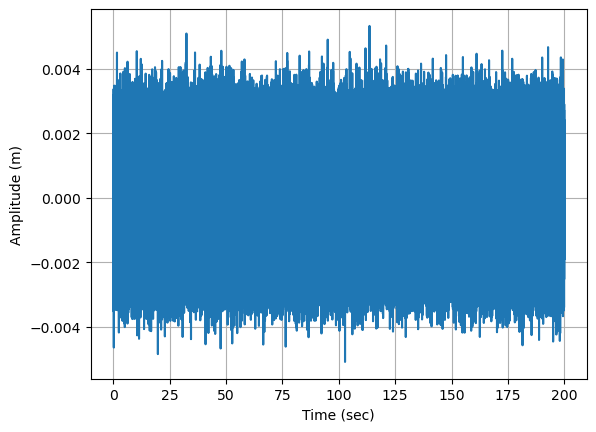

In [ ]:
mu = 0
sigma = 0.001
tt = np.arange(0, 200, 1/fs)
noise = np.random.default_rng().normal(loc=mu, scale=sigma, size=len(tt))

plt.plot(tt, noise)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()

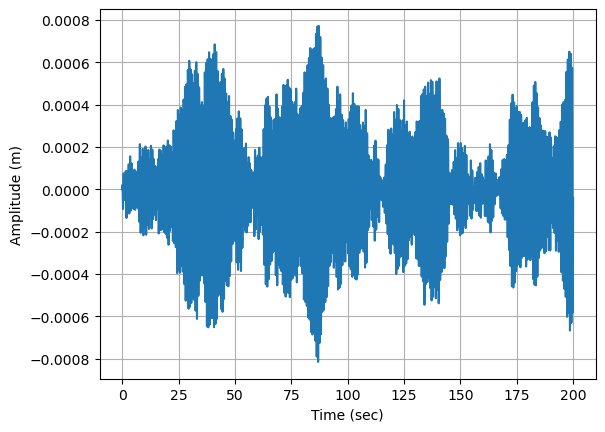

In [ ]:
_, plant_out = forced_response(plant, tt, noise)

plt.plot(tt, plant_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()

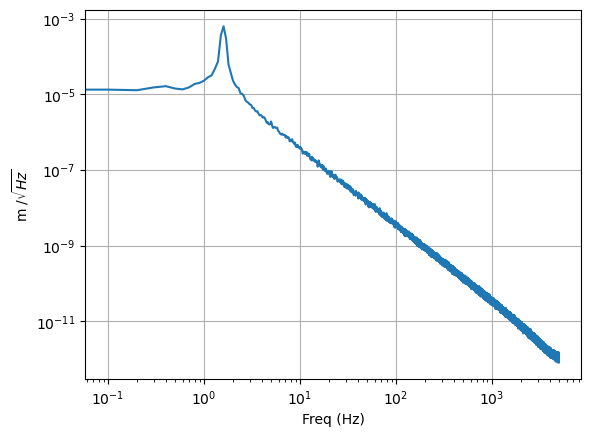

In [ ]:
fftlength = 10
fs = 1/(tt[1] - tt[0])
ff, psd_resp = welch(plant_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp))
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm /$\sqrt{Hz}$')
#plt.xlim([10, 5000])
plt.grid()

# Feedback control using PID

## P control

In [ ]:
pid = 100
plant_closed_P = plant/(1+pid*plant)

In [ ]:
_, plant_closed_P_step  = step_response(plant_closed_P, time)

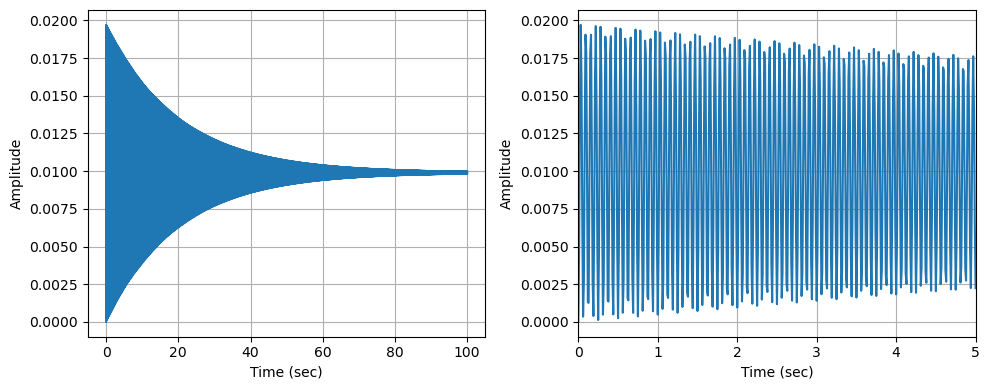

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_closed_P_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_closed_P_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

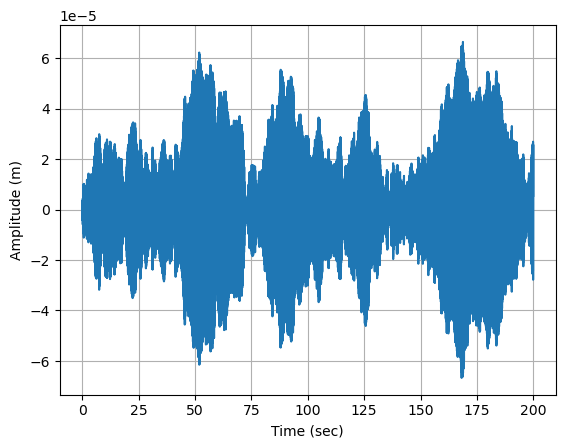

In [ ]:
_, plant_closed_P_out = forced_response(plant_closed_P, tt, noise)

plt.plot(tt, plant_closed_P_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()

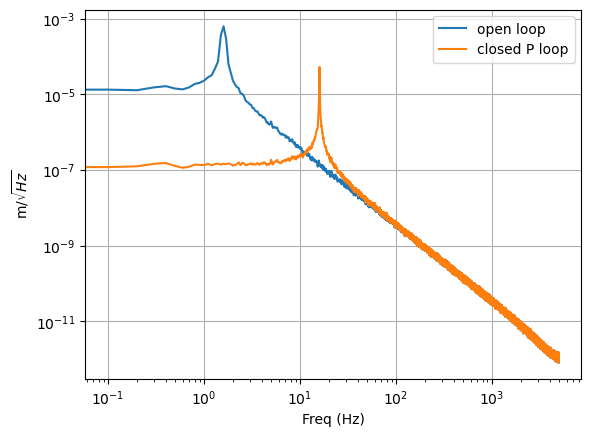

In [ ]:
ff, psd_P_resp = welch(plant_closed_P_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp), label='open loop')
plt.loglog(ff, np.sqrt(psd_P_resp), label='closed P loop')
plt.legend()
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm/$\sqrt{Hz}$')
plt.grid()

## PI control

In [ ]:
pid = 100 + 10 / s
plant_closed_PI = plant/(1+pid*plant)

In [ ]:
_, plant_closed_PI_step  = step_response(plant_closed_PI, time)

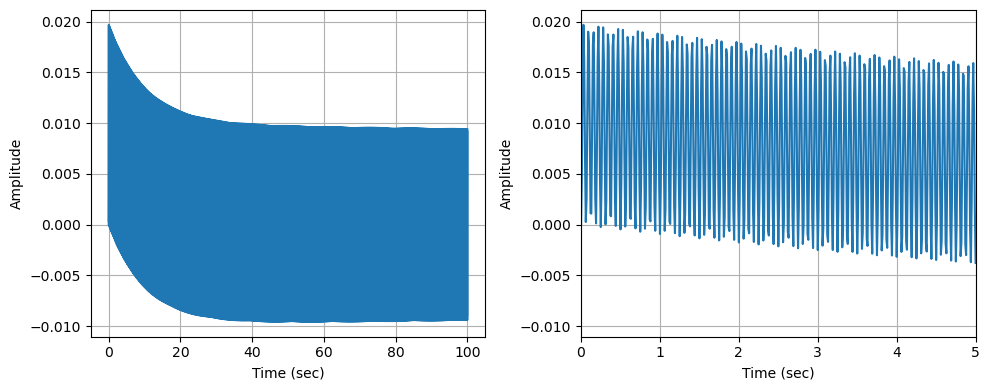

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_closed_PI_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_closed_PI_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

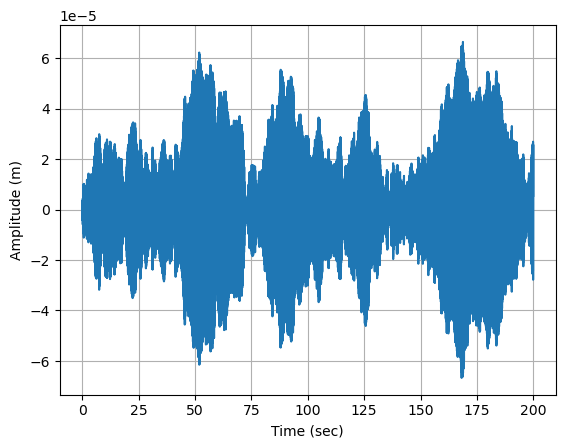

In [ ]:
_, plant_closed_PI_out = forced_response(plant_closed_PI, tt, noise)

plt.plot(tt, plant_closed_P_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()

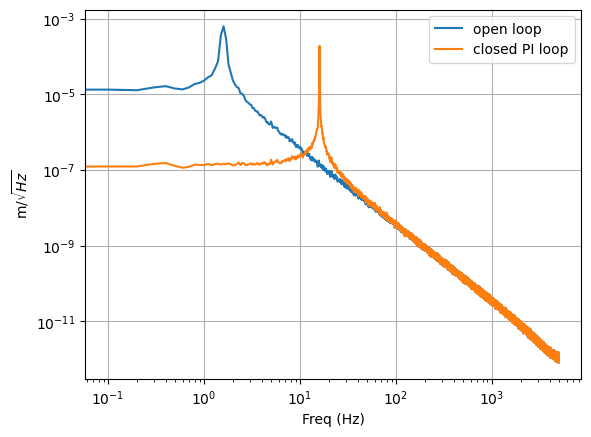

In [ ]:
ff, psd_PI_resp = welch(plant_closed_PI_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp), label='open loop')
#plt.loglog(ff, np.sqrt(psd_P_resp), label='closed P loop')
plt.loglog(ff, np.sqrt(psd_PI_resp), label='closed PI loop')
plt.legend()
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm/$\sqrt{Hz}$')
plt.grid()

## PD control

In [ ]:
pid = 100 + 10 * s
plant_closed_PD = plant/(1+pid*plant)

In [ ]:
_, plant_closed_PD_step  = step_response(plant_closed_PD, time)

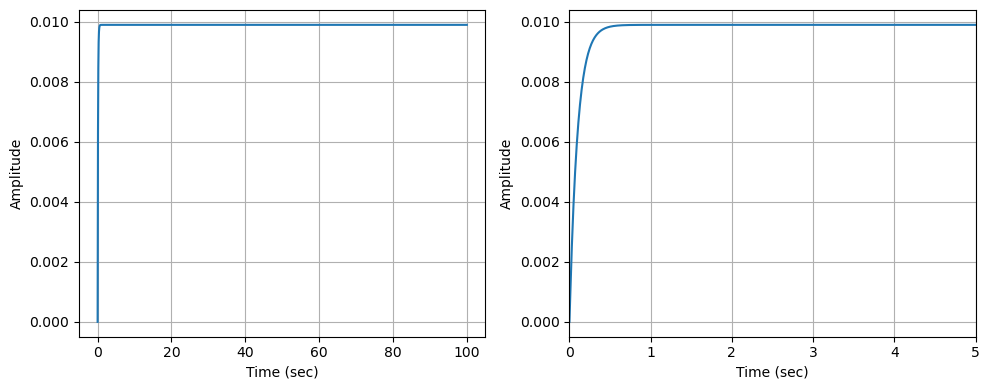

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_closed_PD_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_closed_PD_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

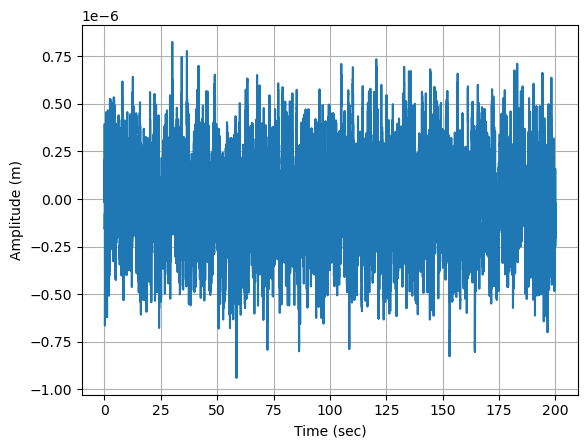

In [ ]:
_, plant_closed_PD_out = forced_response(plant_closed_PD, tt, noise)

plt.plot(tt, plant_closed_PD_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()

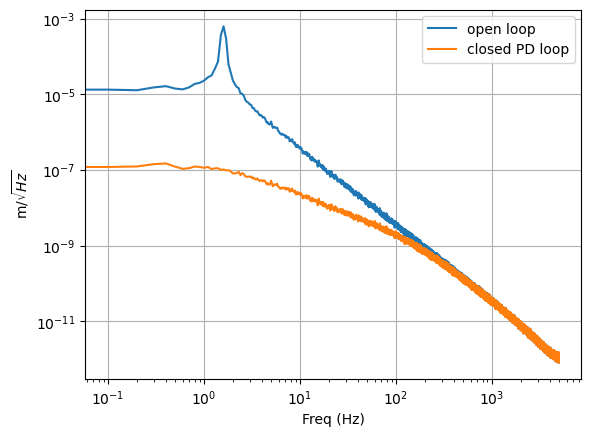

In [ ]:
ff, psd_PD_resp = welch(plant_closed_PD_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp), label='open loop')
plt.loglog(ff, np.sqrt(psd_PD_resp), label='closed PD loop')
plt.legend()
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm/$\sqrt{Hz}$')
plt.grid()

## PID control

In [ ]:
pid = 100 + 10 / s + 10 *s
plant_closed_PID = plant/(1+pid*plant)

In [ ]:
_, plant_closed_PID_step  = step_response(plant_closed_PID, time)

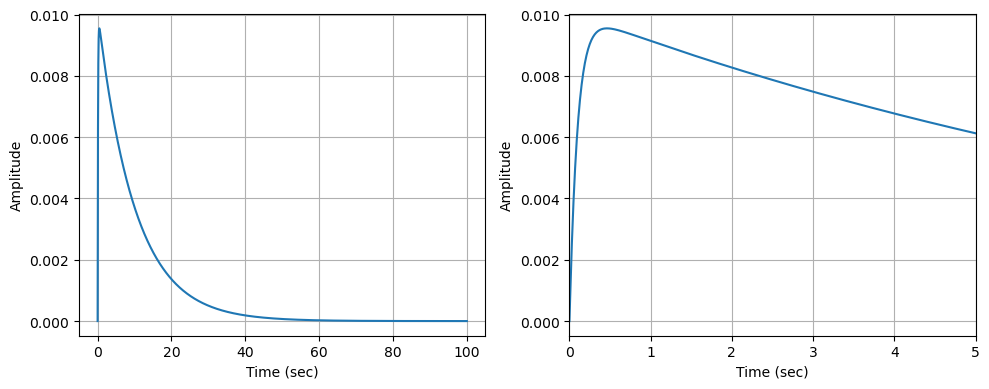

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_closed_PID_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_closed_PID_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

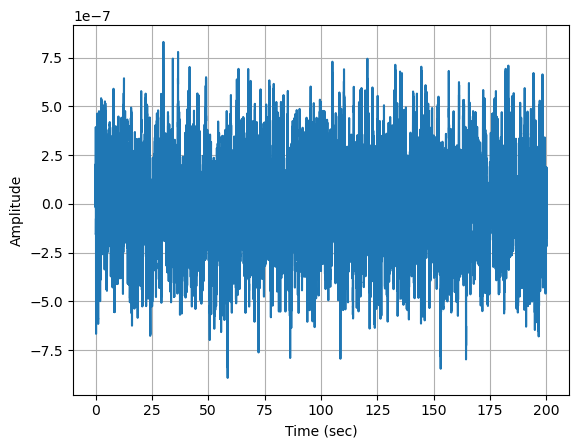

In [ ]:
_, plant_closed_PID_out = forced_response(plant_closed_PID, tt, noise)

plt.plot(tt, plant_closed_PID_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude')
plt.grid()

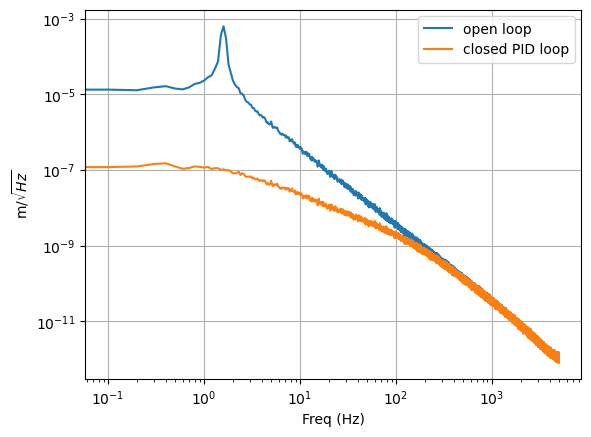

In [ ]:
ff, psd_pid_resp = welch(plant_closed_PID_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp), label='open loop')
plt.loglog(ff, np.sqrt(psd_pid_resp), label='closed PID loop')
plt.legend()
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm/$\sqrt{Hz}$')
#plt.xlim([10, 5000])
plt.grid()

## PID control improved

In [ ]:
pid = 1000 + 500 / s + 500 *s
plant_closed_PID = plant/(1+pid*plant)

In [ ]:
_, plant_closed_PID_step  = step_response(plant_closed_PID, time)

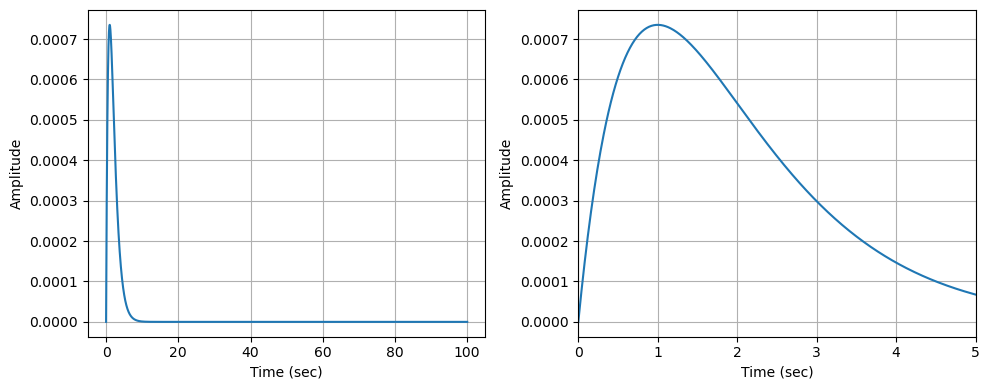

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, plant_closed_PID_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, plant_closed_PID_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

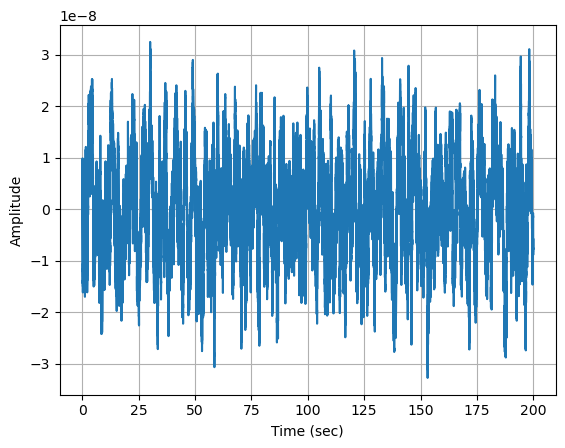

In [ ]:
_, plant_closed_PID_out = forced_response(plant_closed_PID, tt, noise)

plt.plot(tt, plant_closed_PID_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude')
plt.grid()

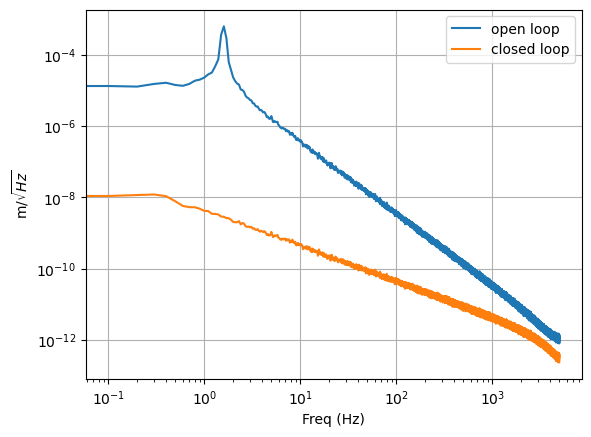

In [ ]:
ff, psd_PID_resp = welch(plant_closed_PID_out, fs=fs, window='hann', nperseg=fftlength * fs,
                            noverlap = fftlength * fs/2, nfft=fftlength * fs)

plt.loglog(ff, np.sqrt(psd_resp), label='open loop')
plt.loglog(ff, np.sqrt(psd_PID_resp), label='closed loop')
plt.legend()
plt.xlabel(r'Freq (Hz)')
plt.ylabel(r'm/$\sqrt{Hz}$')
#plt.xlim([10, 5000])
plt.grid()

## Open loop and closed loop transfer function

In [ ]:
G = pid * plant
G

TransferFunction(array([ 50000., 100000.,  50000.]), array([  1. ,   0.1, 100. ,   0. ]))

In [ ]:
freq = np.arange(0.001, 10000, 0.001)
G_mag, G_phase, _ = G.frequency_response(2*np.pi*freq)
gm , pm , w180 , wc = margin(G)

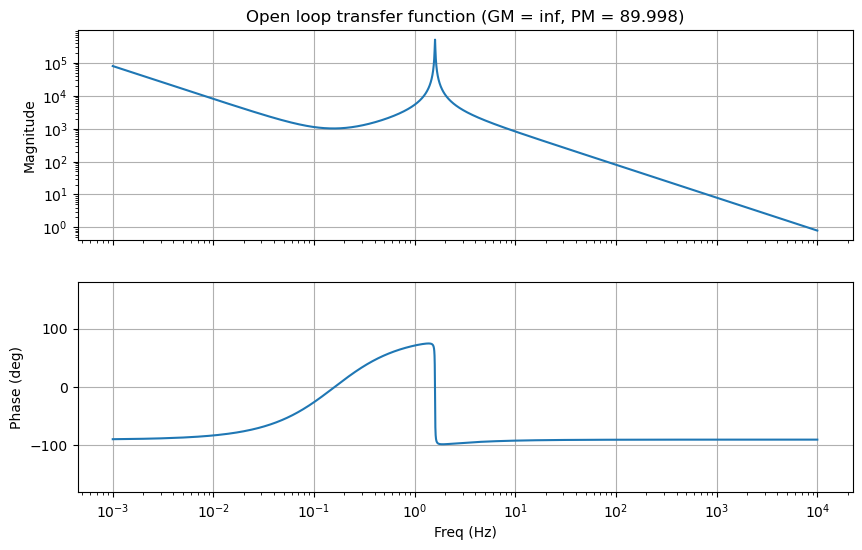

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, G_mag)
axes[0].set_ylabel(r'Magnitude')
axes[0].set_title(r'Open loop transfer function (GM = {:.3f}, PM = {:.3f})'.format(gm, pm))
axes[0].grid()

axes[1].semilogx(freq, G_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

In [ ]:
G_closed = 1/(1+G)
G_closed_mag, G_closed_phase, _ = G_closed.frequency_response(2*np.pi*freq)

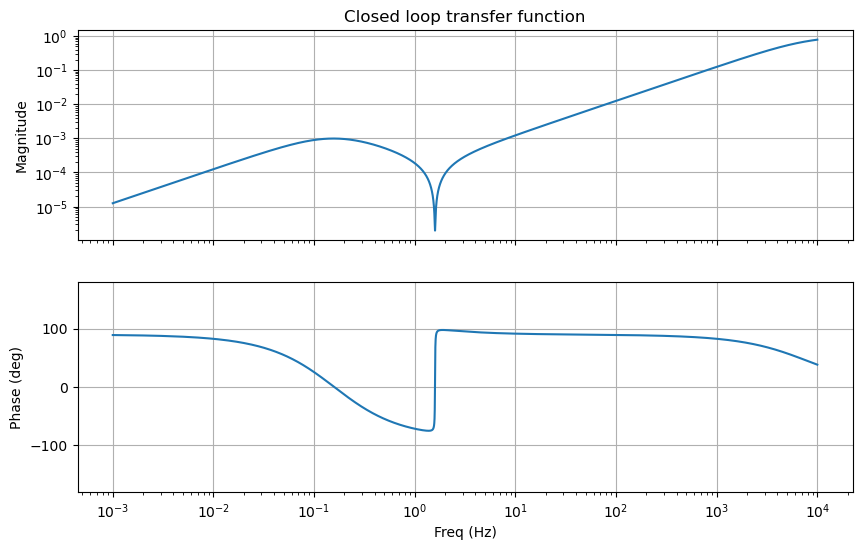

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, G_closed_mag)
axes[0].set_ylabel(r'Magnitude')
axes[0].set_title('Closed loop transfer function')
axes[0].grid()


axes[1].semilogx(freq, G_closed_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

### Adding a low pass fitler

In [ ]:
w_N = 2 * np.pi * 8000
lowpass = w_N**2 /(s**2 + 2* w_N * s + w_N**2)
lowpass

TransferFunction(array([2.52661873e+09]), array([1.00000000e+00, 1.00530965e+05, 2.52661873e+09]))

In [ ]:
lowpass_mag, lowpass_phase, _ = lowpass.frequency_response(2*np.pi*freq)

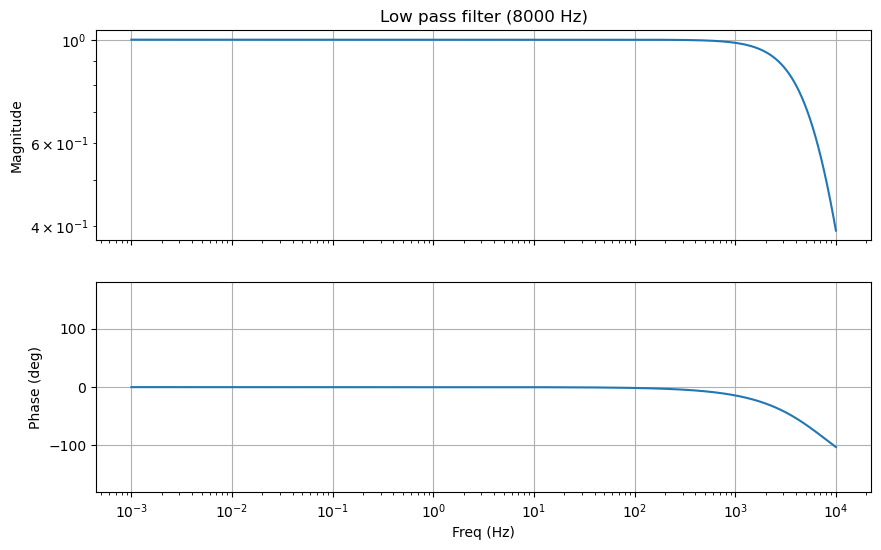

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, lowpass_mag)
#axes[0].set_xlabel('Freq (Hz)')
axes[0].set_ylabel(r'Magnitude')
axes[0].set_title('Low pass filter (8000 Hz)')
axes[0].grid()


axes[1].semilogx(freq, lowpass_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

In [ ]:
G = pid * plant * lowpass
G

TransferFunction(array([1.26330936e+14, 2.52661873e+14, 1.26330936e+14]), array([1.00000000e+00, 1.00531065e+05, 2.52662888e+09, 2.62714969e+08,
       2.52661873e+11, 0.00000000e+00]))

In [ ]:
G_mag, G_phase, _ = G.frequency_response(2*np.pi*freq)
f_0dB = freq[np.argmin(np.abs(G_mag-1))]
f_180deg = freq[np.argmin(G_phase+np.pi)]
gm , pm , w180 , wc = margin(G)

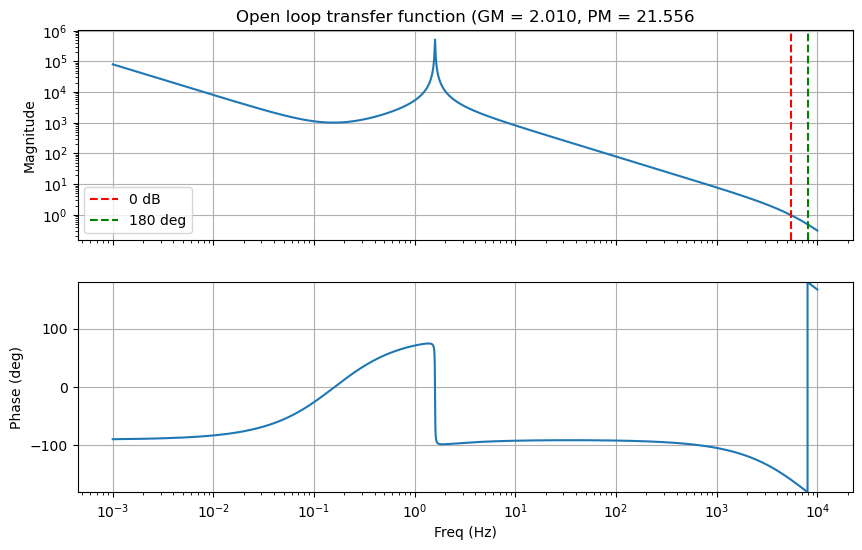

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
axes[0].loglog(freq, G_mag)
axes[0].axvline(x = f_0dB, color='r', linestyle='--', label='0 dB')
axes[0].axvline(x = f_180deg, color='g', linestyle='--', label = '180 deg')
axes[0].set_ylabel(r'Magnitude')
axes[0].set_title(r'Open loop transfer function (GM = {:.3f}, PM = {:.3f}'.format(gm, pm))
axes[0].legend()
axes[0].grid()

axes[1].semilogx(freq, G_phase*180/np.pi)
axes[1].set_xlabel('Freq (Hz)')
axes[1].set_ylabel(r'Phase (deg)')
axes[1].set_ylim([-180, 180])
axes[1].grid()

## Understand closed loop response

In [ ]:
G_closed = 1/(1+G)
_, G_closed_step  = step_response(G_closed , time)

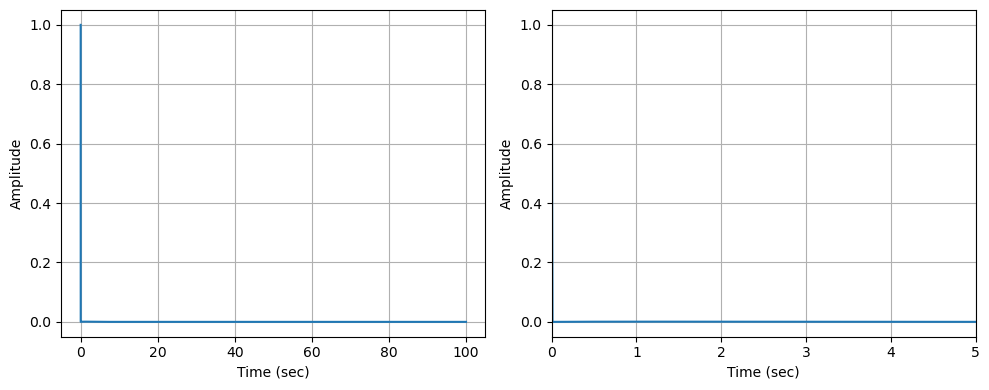

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, G_closed_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, G_closed_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 5])

fig.tight_layout()

## Make gain margin negative dB

In [ ]:
G = G * 2.011
G_closed = 1/(1+G)
G_closed_mag, G_closed_phase, _ = G_closed.frequency_response(2*np.pi*freq)

In [ ]:
_, G_closed_step  = step_response(G_closed , time)

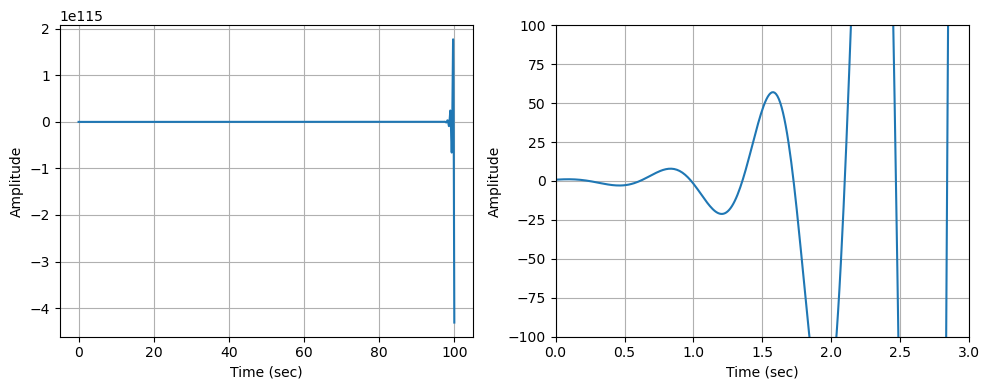

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].plot(time, G_closed_step)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')
axes[0].grid()

axes[1].plot(time, G_closed_step)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')
axes[1].grid()
axes[1].set_xlim([0, 3])
axes[1].set_ylim([-100, 100])

fig.tight_layout()

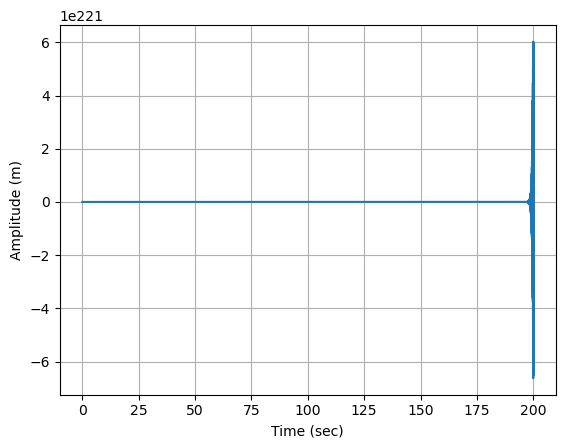

In [ ]:
plant_closed_G = plant/(1+G)
_, plant_closed_G_out = forced_response(plant_closed_G, tt, noise)

plt.plot(tt, plant_closed_G_out)
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude (m)')
plt.grid()